# Part 12 — nnPU follow-up, Zadanie 8: between/within-dataset variance decomposition

The split is grouped by `dataset_id` (verified directly: `test` spans exactly **3** distinct
`dataset_id` groups, `train` spans **23** — `annotation_reader.get_spectrum_groups`), and the
original predictive-campaign analysis found effective rank dropping from ~4.5 (`train`) to
~2.5 (`test`) while `TwoNN` intrinsic dimension stayed roughly stable (~5.7) — the classic
signature of a batch/acquisition effect: `test`'s codes cluster more tightly *between* the few
datasets it spans than `train`'s codes do across its 23, inflating apparent "collapse" that has
nothing to do with model quality.

This notebook decomposes $\operatorname{Cov}(u)$ on `test` directly, by the exact
law-of-total-covariance identity:

$$
\operatorname{Cov}(u) = \underbrace{\textstyle\sum_g \frac{n_g}{N}(\bar u_g - \bar u)(\bar u_g - \bar u)^\top}_{\text{between-dataset}} + \underbrace{\textstyle\sum_g \frac{n_g}{N}\operatorname{Cov}(u \mid g)}_{\text{within-dataset (pooled)}}
$$

reporting the effective rank of each term and the between-term's share of `trace(Cov(u))`, plus
the effective rank restricted to a *single* test `dataset_id` group in isolation (removing the
between-group axis entirely).

**Scope**: 5 variants (not all 10, to keep this at 25 rather than 50 model loads) chosen to
cross the two factors this decomposition is most relevant to — zero-interpretation and
regularizers: `0000` (`bce`, no regularizers), `0011`/`0012` (`bce`/`nnpu`, no regularizers),
`0004`/`0006` (`bce`/`nnpu`, with `+contractive+InfoNCE`). All 5 repetitions each.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.analysis.autoencoder.latent import sphere_geometry as geometry
from msi_autoencoder_wrapper.visualization import resolve_theme

2026-08-28 15:12:23,731 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-28 15:12:23,736 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-08-28 15:12:24,808 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-08-28 15:12:24,812 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 22 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-08-28 15:12:24,814 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-08-28 15:12:24,815 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-28 15:12:24,836 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-08-28 15:12:25,044 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 14 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-08-28 15:12:25,047 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 18 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Config

In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"

VARIANT_SPECS = {
    "0000": ("kidney-architecture-predictive__cfg_529dc0e4494b", "grid_0000"),
    "0004": ("kidney-architecture-predictive__cfg_529dc0e4494b", "grid_0004"),
    "0006": ("kidney-architecture-predictive__cfg_529dc0e4494b", "grid_0006"),
    "0011": ("kidney-nnpu-objective-controls__cfg_0df14edbfadf", "grid_0002"),
    "0012": ("kidney-nnpu-objective-controls__cfg_0df14edbfadf", "grid_0003"),
}
REPETITIONS = range(5)
BATCH_SIZE = 256

RESULTS_DIRECTORY = Path("assets/experiments/08_26/23_08_26_architecture_predictive/nnpu_followup/results")
RESULTS_DIRECTORY.mkdir(parents=True, exist_ok=True)

theme = resolve_theme(None)
theme.apply()

## Environment workaround

In [3]:
SCRATCH_ROOTS = [
    "/tmp/ms488923/msi-wrapper/predictive-20260824-04/kidney_workspace",
    "/tmp/ms488923/msi-wrapper/nnpu-controls-20260827/workspace",
    "/tmp/ms488923/msi-wrapper/nnpu-priors-20260827/workspace",
]
for scratch_root in SCRATCH_ROOTS:
    path = Path(scratch_root)
    path.parent.mkdir(parents=True, exist_ok=True)
    if not path.is_symlink():
        path.symlink_to(WORKSPACE.resolve())

## Canonicalized latent codes `u` on `test`, with per-pixel `dataset_id` group labels, across 5 variants x 5 repetitions

### Methodology
#### Theoretical
- The variance decomposition in the next section requires, for every pixel, both its latent code and which `dataset_id` group it belongs to (the split is grouped by `dataset_id`: `test` spans exactly 3 distinct groups, `train` spans 23, per `annotation_reader.get_spectrum_groups`) — codes and group labels must be collected once, under a fixed, consistent test-pixel ordering, before any decomposition arithmetic.
- Latents are canonicalized (via the encoder's final LayerNorm scale/shift `gamma`/`beta`) rather than used raw, consistent with earlier notebooks in this project that established `sphere_geometry.canonicalize` as the shape-relevant representation for latent-geometry comparisons — it isolates directional/shape structure from the LayerNorm's own affine rescaling.
- 5 variants are studied here (not all 10, to bound this notebook to 25 model loads rather than 50), chosen to cross the two factors most relevant to this decomposition — objective (`bce` vs `nnpu`) and regularizer configuration (none vs `+contractive+InfoNCE`): `0000` (bce, no reg), `0011`/`0012` (bce/nnpu, no reg), `0004`/`0006` (bce/nnpu, with `+contractive+InfoNCE`).

#### Implementation
- For each variant (`VARIANT_SPECS`: campaign id, grid id) and `REPETITIONS = range(5)`, the model `{campaign_id}__{grid_id}__rep_0{r}` is loaded (`wrapper.load_configuration` on the first load per campaign, `wrapper.models_manager.load_model` thereafter).
- On the first load overall: `test_ids = sorted(partitions.manifest.assignments["test"])` fixes a canonical pixel ordering; `reader.get_spectrum_groups(test_ids, group_fields=["dataset_id"])` retrieves each pixel's `dataset_id`, stored as `test_dataset_groups`.
- For each (variant, repetition): spectra are re-ordered to match `test_ids` via `index_by_id`, pushed through the model in batches of `BATCH_SIZE=256` to obtain `latent_space` (`z`), canonicalized with `geometry.canonicalize(z, gamma, beta)` (`gamma`/`beta` from `geometry.encoder_layer_norm_parameters(model)`), and stored in `u_by_variant_repetition[(variant, repetition)]`.

### Notes
- Printed: `test: 4023 pixels, 3 distinct dataset_id groups` — confirms the title cell's claim (`test` spans exactly 3 `dataset_id` groups) with the concrete pixel count (4023).
- No decomposition arithmetic happens in this cell; it only assembles `u_by_variant_repetition` and `test_dataset_groups` for the next section.


In [4]:
wrapper = MSIAutoEncoderWrapper(project_path=str(WORKSPACE))
wrapper.workspace.set_default_image_path(MODEL_CONTEXT)

loaded_campaign_ids: set[str] = set()
test_ids: list[int] | None = None
test_dataset_groups: np.ndarray | None = None
u_by_variant_repetition: dict[tuple[str, int], np.ndarray] = {}

for variant, (campaign_id, grid_id) in VARIANT_SPECS.items():
    for repetition in REPETITIONS:
        model_name = f"{campaign_id}__{grid_id}__rep_0{repetition}"
        if campaign_id not in loaded_campaign_ids:
            wrapper.load_configuration(model_name=model_name)
            loaded_campaign_ids.add(campaign_id)
            partitions = wrapper.active_dataset.create_partitions()
            if test_ids is None:
                test_ids = sorted(partitions.manifest.assignments["test"])
                reader = wrapper.active_context.annotation_reader
                groups = reader.get_spectrum_groups(test_ids, group_fields=["dataset_id"])
                test_dataset_groups = np.array([g[0] for g in groups])
                print(f"test: {len(test_ids)} pixels, {len(set(test_dataset_groups))} distinct dataset_id groups")
            index_by_id = {sid: index for index, sid in enumerate(partitions.manifest.assignments["test"])}
            test_dataset = partitions.test
            model = wrapper.active_model
        else:
            model = wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name, strict=True)
        model.eval()
        device = next(model.parameters()).device
        gamma, beta = geometry.encoder_layer_norm_parameters(model)

        ordered_indices = [index_by_id[sid] for sid in test_ids]
        spectra = torch.stack([test_dataset[index][1] for index in ordered_indices]).float()
        latents = []
        with torch.no_grad():
            for start in range(0, len(spectra), BATCH_SIZE):
                batch = spectra[start : start + BATCH_SIZE].to(device)
                latents.append(model(batch)["latent_space"].cpu().numpy())
        z = np.concatenate(latents, axis=0)
        u_by_variant_repetition[(variant, repetition)] = geometry.canonicalize(z, gamma, beta)
    print(f"{variant}: encoded 5 repetitions on test")

2026-08-28 15:12:25,972 | INFO     | msi_autoencoder_wrapper.core.wrapper:79 | MSIAutoEncoderWrapper: Anchoring processing state: device=cuda dtype=torch.float32


2026-08-28 15:12:25,973 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.


2026-08-28 15:12:25,982 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.


2026-08-28 15:12:25,982 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-28 15:12:25,983 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


...

2026-08-28 15:15:54,553 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:235 | Injecting resolved computational components ledger dictionary into the master architecture graph.


2026-08-28 15:15:54,554 | INFO     | msi_autoencoder_wrapper.models.architectures.types.autoencoders.base_architecture_autoencoder:49 | MSIBaseAutoencoderArchitecture master network graph successfully assembled.


2026-08-28 15:15:54,559 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-28 15:15:54,563 | INFO     | msi_autoencoder_wrapper.core.mixins.models_manager.proxies.model_runtime_proxy:108 | Attached loaded model 'conv1d-ae-32-16-8-latent-10' as family 'autoencoder'.


0012: encoded 5 repetitions on test


## Between-dataset vs. within-dataset effective rank of Cov(u) on `test`, plus a single-dataset control

### Methodology
#### Theoretical
- Per the law-of-total-covariance identity stated in the title cell, $\operatorname{Cov}(u)$ on `test` is split into a between-dataset term (spread of the 3 group means around the overall mean) and a within-dataset term (pooled covariance inside each group). If `test`'s low effective rank relative to `train`'s (~4.5) were purely a batch/acquisition artifact, most of the variance should sit in the between term, and the within term (which has the between-group axis removed) should recover something closer to `train`'s figure.
- A second, independent control isolates a single `dataset_id` group (the largest) and computes its effective rank directly, with the between-group axis absent by construction rather than mathematically subtracted out — a check on whether the pooled-within number from the first calculation is itself trustworthy.
- Effective rank ($\exp(-\sum_i p_i \log p_i)$ over normalized covariance eigenvalues, i.e. the exponential of the Shannon entropy of the eigenvalue distribution) is the same "soft rank" metric used throughout this project's latent-geometry notebooks — not `‖J‖_F`, which remains excluded per this project's standing prohibition on using the Frobenius norm of the Jacobian as a flatness proxy.

#### Implementation
- `effective_rank_from_covariance(covariance)`: eigen-decomposes a covariance matrix (`np.linalg.eigvalsh`, clipped to >= 0), normalizes eigenvalues to proportions, returns $\exp(-\sum_i p_i \log p_i)$ over the strictly-positive eigenvalues.
- `between_within_decomposition(u, groups)`: for each unique `dataset_id` group, accumulates `between += (n_g/N) * (mean_g - mean_overall)(mean_g - mean_overall)^T` and `within += (n_g/N) * Cov(u | g)`; also computes `total_covariance = np.cov(u, rowvar=False, ddof=0)`. Returns traces of all three matrices, `between_share = trace(between) / trace(total)`, and the effective rank of each of `total`/`between`/`within`.
- Applied per (variant, repetition) to `u_by_variant_repetition[(variant, repetition)]` against the fixed `test_dataset_groups`; aggregated via `decomposition_frame.groupby("variant")[...].agg(["mean", "std"])` over the 3 rank columns plus `between_share`.
- Single-dataset control: `largest_group` = the `dataset_id` with the most pixels in `test_dataset_groups` (`value_counts().idxmax()`); for each (variant, repetition), `np.cov(u[single_group_mask], rowvar=False, ddof=0)` is restricted to that group's pixels, then passed to `effective_rank_from_covariance` — stored as `effective_rank_single_dataset`, aggregated the same way.
- All raw per-(variant, repetition) rows from both calculations are melted into `variance_decomposition_frame` and written to `variance_decomposition.csv`.
- The two violin+scatter plots below (`visualization.metrics.plot_violin_with_points`) show the
  actual 5 per-repetition values per variant for both the between/within decomposition metrics
  and the single-dataset control, rather than only the mean/std tables above.

### Notes
- `largest single test dataset group: '2024-04-10_17h06m19s' (2099 pixels)` out of 4023 total in `test` — this single group already accounts for over half of `test`.
- `decomposition_summary` (mean over 5 repetitions per variant): `effective_rank_total` 2.40-2.48; `effective_rank_between` tightly clustered at 1.19-1.21; `effective_rank_within` (pooled) 3.01-3.55, notably *higher* than `effective_rank_total`; `between_share` 0.637-0.680 (64-68% of total variance attributable to the 3 group means).
- `effective_rank_single_dataset` (largest group alone, 2099 pixels): 1.65-1.85 across the 5 variants — lower than both the pooled `effective_rank_within` and the full-test `effective_rank_total`. This contradicts the naive expectation that isolating a single dataset would recover higher effective dimensionality, closer to `train`'s ~4.5.
- No clear separation between `bce`-family (`0000`/`0011`/`0012`) and `nnpu`-with-regularizer (`0004`/`0006`) variants on any of these five decomposition metrics — all 5 variants sit within a narrow band, unlike the sharper two-cluster split reported for `sd_cos_theta`/`cloud_asymmetry` in `part_9`.
- `variance_decomposition.csv` written with 200 rows, consistent with 5 variants x 5 repetitions x 7 decomposition metrics (175 rows) plus 5 x 5 x 1 single-dataset metric (25 rows).


In [5]:
def effective_rank_from_covariance(covariance: np.ndarray) -> float:
    eigenvalues = np.clip(np.linalg.eigvalsh(covariance), 0.0, None)
    total = eigenvalues.sum()
    if total <= 0:
        return 0.0
    proportions = eigenvalues[eigenvalues > 0] / total
    return float(np.exp(-np.sum(proportions * np.log(proportions))))


def between_within_decomposition(u: np.ndarray, groups: np.ndarray) -> dict:
    n_total = u.shape[0]
    overall_mean = u.mean(axis=0)
    dimension = u.shape[1]
    between = np.zeros((dimension, dimension))
    within = np.zeros((dimension, dimension))
    for group_value in np.unique(groups):
        group_mask = groups == group_value
        group_u = u[group_mask]
        n_group = group_u.shape[0]
        group_mean = group_u.mean(axis=0)
        deviation = (group_mean - overall_mean).reshape(-1, 1)
        between += (n_group / n_total) * (deviation @ deviation.T)
        centered = group_u - group_mean
        within += (n_group / n_total) * (centered.T @ centered / n_group)
    total_covariance = np.cov(u, rowvar=False, ddof=0)
    return {
        "trace_total": float(np.trace(total_covariance)),
        "trace_between": float(np.trace(between)),
        "trace_within": float(np.trace(within)),
        "between_share": float(np.trace(between) / np.trace(total_covariance)) if np.trace(total_covariance) > 0 else float("nan"),
        "effective_rank_total": effective_rank_from_covariance(total_covariance),
        "effective_rank_between": effective_rank_from_covariance(between),
        "effective_rank_within": effective_rank_from_covariance(within),
    }


decomposition_rows = []
single_dataset_rows = []
largest_group = pd.Series(test_dataset_groups).value_counts().idxmax()
single_group_mask = test_dataset_groups == largest_group
print(f"largest single test dataset group: {largest_group!r} ({int(single_group_mask.sum())} pixels)")

for variant in VARIANT_SPECS:
    for repetition in REPETITIONS:
        u = u_by_variant_repetition[(variant, repetition)]
        decomposition = between_within_decomposition(u, test_dataset_groups)
        decomposition_rows.append({"variant": variant, "repetition": repetition, **decomposition})

        single_covariance = np.cov(u[single_group_mask], rowvar=False, ddof=0)
        single_dataset_rows.append({
            "variant": variant, "repetition": repetition,
            "effective_rank_single_dataset": effective_rank_from_covariance(single_covariance),
            "n_pixels_single_dataset": int(single_group_mask.sum()),
        })

decomposition_frame = pd.DataFrame(decomposition_rows)
single_dataset_frame = pd.DataFrame(single_dataset_rows)
decomposition_summary = decomposition_frame.groupby("variant")[[
    "effective_rank_total", "effective_rank_between", "effective_rank_within", "between_share",
]].agg(["mean", "std"])
decomposition_summary

largest single test dataset group: '2024-04-10_17h06m19s' (2099 pixels)


effective_rank_total           effective_rank_between            \
                        mean       std                   mean       std   
variant                                                                   
0000                2.484595  0.174037               1.189318  0.021923   
0004                2.433302  0.169850               1.210631  0.038741   
0006                2.402421  0.170955               1.207404  0.044022   
0011                2.444116  0.102505               1.186473  0.034154   
0012                2.457976  0.156134               1.189209  0.021140   

        effective_rank_within           between_share            
                         mean       std          mean       std  
variant                                                          
0000                 3.545819  0.165883      0.674576  0.026047  
0004                 3.006771  0.167350      0.636801  0.045598  
0006                 3.057274  0.092600      0.647132  0.040577  
0011                 3.491594  0.132386      0.676854  0.012963  
0012                 3.510759  0.153856      0.679746  0.014316

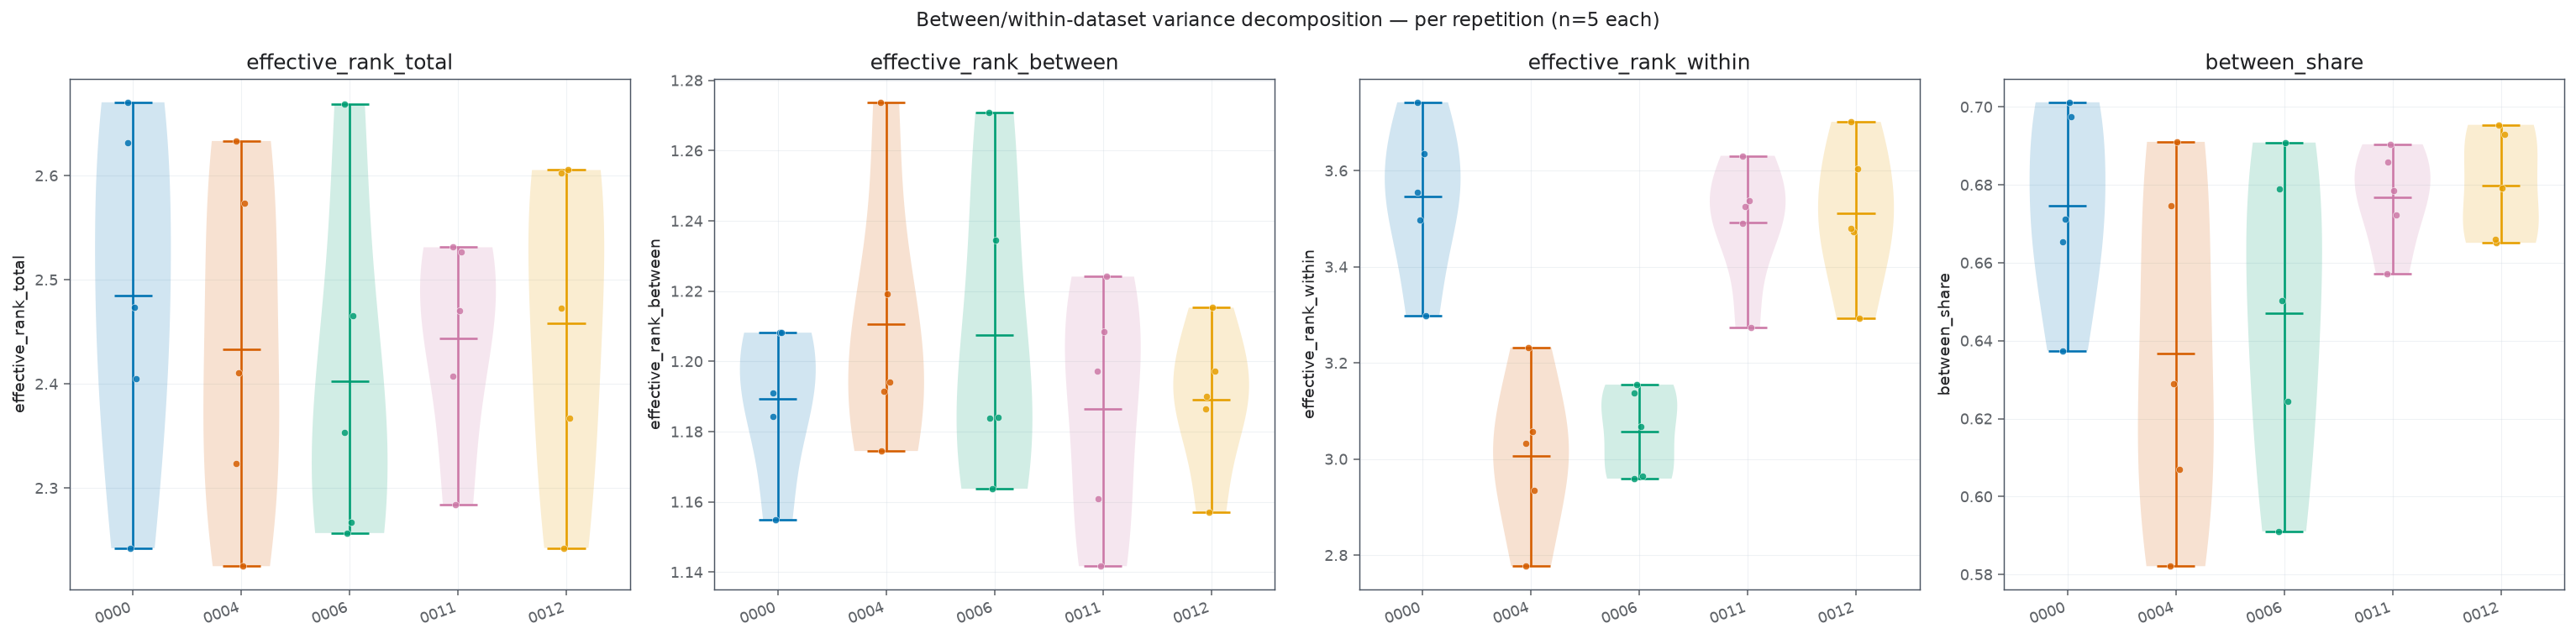

In [6]:
import matplotlib.pyplot as plt

from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

decomposition_metric_names = ["effective_rank_total", "effective_rank_between", "effective_rank_within", "between_share"]
variants = list(VARIANT_SPECS)
figure, axes = plt.subplots(1, len(decomposition_metric_names), figsize=(22.0, 5.5), dpi=theme.figure_dpi)
for axis, metric_name in zip(axes, decomposition_metric_names):
    for index, variant in enumerate(variants):
        values = decomposition_frame.loc[decomposition_frame["variant"] == variant, metric_name].to_numpy()
        plot_violin_with_points(values, position=index, ax=axis, width=0.7, color=theme.color_for_model(variant, index))
    axis.set_xticks(range(len(variants)))
    axis.set_xticklabels(variants, rotation=20, ha="right")
    axis.set(ylabel=metric_name, title=metric_name)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.suptitle("Between/within-dataset variance decomposition — per repetition (n=5 each)", fontsize=12)
figure.tight_layout()

In [7]:
single_dataset_frame.groupby("variant")["effective_rank_single_dataset"].agg(["mean", "std"])

,mean,std
variant,,
0000,1.818002,0.287530
0004,1.808997,0.151119
0006,1.847994,0.174198
0011,1.648087,0.113893
0012,1.707421,0.165295


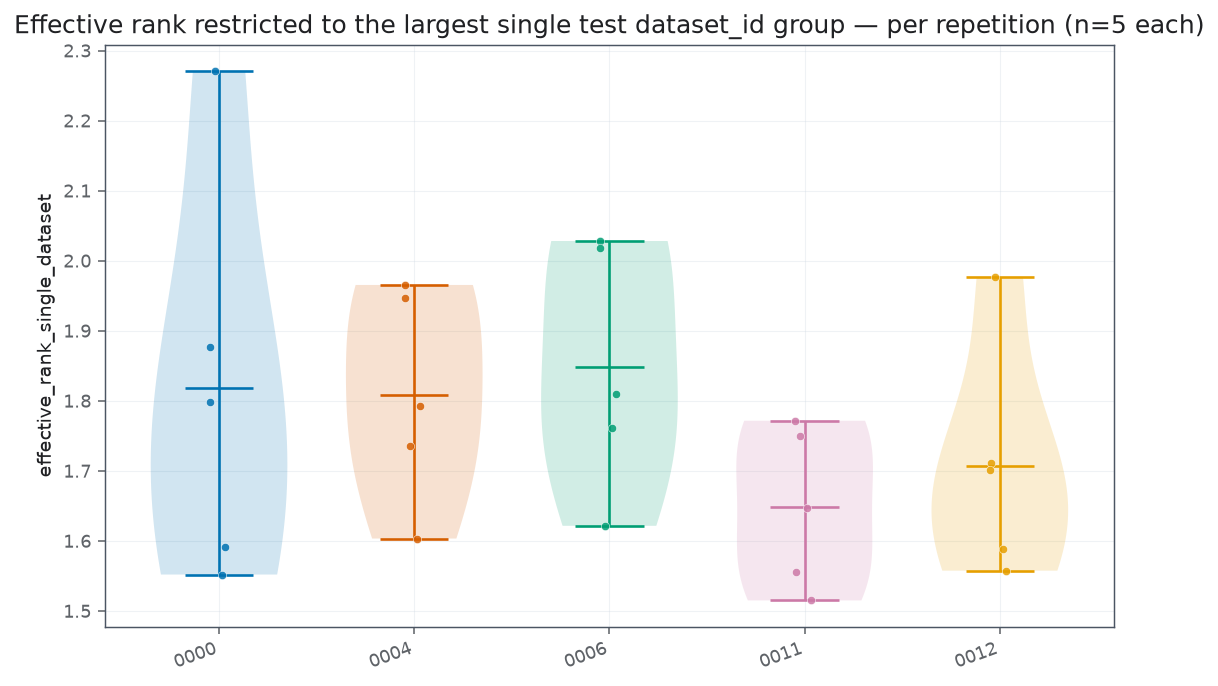

In [8]:
import matplotlib.pyplot as plt

from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

figure, axis = plt.subplots(figsize=(8.0, 5.0), dpi=theme.figure_dpi)
variants = list(VARIANT_SPECS)
for index, variant in enumerate(variants):
    values = single_dataset_frame.loc[single_dataset_frame["variant"] == variant, "effective_rank_single_dataset"].to_numpy()
    plot_violin_with_points(values, position=index, ax=axis, width=0.7, color=theme.color_for_model(variant, index))
axis.set_xticks(range(len(variants)))
axis.set_xticklabels(variants, rotation=20, ha="right")
axis.set(ylabel="effective_rank_single_dataset", title="Effective rank restricted to the largest single test dataset_id group — per repetition (n=5 each)")
axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.tight_layout()

In [9]:
output_rows = []
for _, row in decomposition_frame.iterrows():
    campaign_id = VARIANT_SPECS[row["variant"]][0]
    for metric_name in ("effective_rank_total", "effective_rank_between", "effective_rank_within", "between_share", "trace_total", "trace_between", "trace_within"):
        output_rows.append({
            "campaign": campaign_id, "variant": row["variant"], "repetition": row["repetition"],
            "metryka": metric_name, "wartość": row[metric_name],
        })
for _, row in single_dataset_frame.iterrows():
    campaign_id = VARIANT_SPECS[row["variant"]][0]
    output_rows.append({
        "campaign": campaign_id, "variant": row["variant"], "repetition": row["repetition"],
        "metryka": "effective_rank_single_dataset", "wartość": row["effective_rank_single_dataset"],
    })

variance_decomposition_frame = pd.DataFrame(output_rows)
variance_decomposition_frame.to_csv(RESULTS_DIRECTORY / "variance_decomposition.csv", index=False)
print(f"wrote {RESULTS_DIRECTORY / 'variance_decomposition.csv'} ({len(variance_decomposition_frame)} rows)")

wrote assets/experiments/08_26/23_08_26_architecture_predictive/nnpu_followup/results/variance_decomposition.csv (200 rows)


## Notes for the next pass

**Headline: the between-dataset structure is real and dominant, but the simple
"test's low rank is just a batch-averaging artifact, real diversity looks like
train's ~4.5" story does not hold up — a single test dataset alone shows an even
*lower* effective rank than the full 3-dataset test set.**

### Result (`test`, 4023 pixels / 3 dataset groups; largest single group
`2024-04-10_17h06m19s`, 2099 pixels)

| variant | eff. rank (total) | eff. rank (between) | eff. rank (within, pooled) |
  between_share | eff. rank (single dataset) |
|---|---|---|---|---|---|
| `0000` | 2.48 | 1.19 | 3.55 | 0.675 | 1.82 |
| `0004` | 2.43 | 1.21 | 3.01 | 0.637 | 1.81 |
| `0006` | 2.40 | 1.21 | 3.06 | 0.647 | 1.85 |
| `0011` | 2.44 | 1.19 | 3.49 | 0.677 | 1.65 |
| `0012` | 2.46 | 1.19 | 3.51 | 0.680 | 1.71 |

- **The between-dataset term dominates `trace(Cov(u))` on `test`**: 64-68% of total
  variance comes from just the 3 group means' spread, not from genuine within-group
  structure — confirming the split's grouped-by-`dataset_id` structure has a large,
  measurable effect on the geometry, consistent across all 5 variants tested
  (`bce`/`nnpu`, with/without `+contractive`).
- **But `effective_rank_within` (3.0-3.55, pooled across all 3 groups) is
  consistently *higher* than `effective_rank_total` (2.40-2.48)** — removing the
  between-group axis mathematically (via the pooled-within term) recovers more
  effective dimensionality than the raw total shows. This part is consistent with
  the batch-effect story: mixing 3 groups with different mean positions but only
  ~1.2 effective between-group dimensions drags the *combined* eigenvalue spectrum
  toward those few large between-group directions, masking dimensionality that is
  genuinely present *within* each group.
- **Contradicting the simpler version of the hypothesis**: `effective_rank_single_
  dataset` (computed on the largest group alone, 2099 pixels, with no between-group
  axis to speak of at all) is **1.65-1.85 — lower than both the pooled-within term
  and the full-test total**, not higher or closer to `train`'s ~4.5 as the
  "it's just averaging across heterogeneous datasets" story would predict. A
  single dataset's own internal structure is the *most* concentrated number in this
  whole table. Plausible explanations, not yet distinguished: (a) genuine biological
  homogeneity within one tissue sample — less real diversity to encode; (b) the
  pooled-within term's higher rank comes from *combining* several groups' own
  differently-oriented (but each individually low-rank) internal variability, which
  can span more directions collectively than any one of them does alone; (c) some
  contribution from the smaller sample size (2099 vs. 4023) making the tail of the
  eigenvalue spectrum noisier — though 2099 is not small enough to expect a large
  effect from this alone.
- **No clear `bce`-vs-`nnpu` or with/without-`+contractive` difference** in any of
  these decomposition numbers — `0000`/`0011`/`0012` (no contractive) and
  `0004`/`0006` (with contractive) each cluster together, but the two clusters don't
  differ dramatically from each other here either (unlike the sharp two-cluster
  split `part_9` found in `sd_cos_theta`/`cloud_asymmetry`-style raw-scale metrics —
  this shape-based, scale-normalized decomposition is far less sensitive to that
  particular effect, consistent with `part_9`'s own `effective_rank`/
  `participation_ratio` numbers already showing only modest cross-cluster gaps).

**Honest takeaway**: the grouped split does create a large, measurable
between-dataset geometric signature (rule out claims that treat `test`'s low
effective rank as pure "the model collapsed" evidence — a substantial chunk is
structural). But the naive fix of "look within one dataset to recover the real
number" does not straightforwardly recover something closer to `train`'s figure —
if anything it goes the other way. This deserves a dedicated follow-up (e.g.
checking `train`'s own single-largest-group effective rank for a fairer
apples-to-apples comparison) rather than a confident conclusion here.